  featureNam featureDes                         geometry
0         TJ       None  POINT Z (-117.12628 32.55124 0)
1         PB       None  POINT Z (-117.10761 32.44637 0)
EPSG:4326


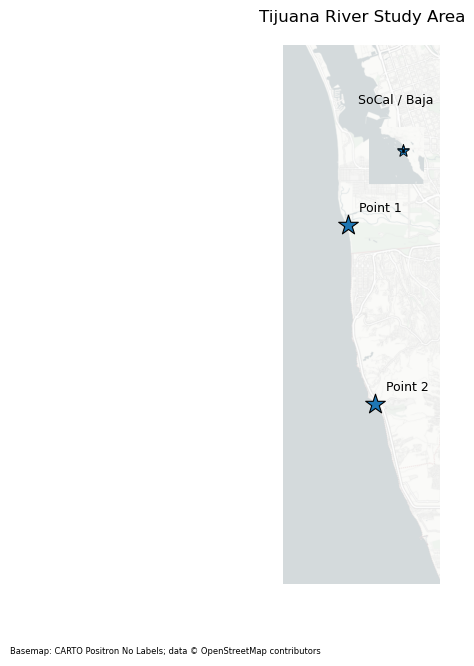

In [6]:
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as cx
from matplotlib.patches import Rectangle
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# --------------------------------------------------
# File path
# --------------------------------------------------
outflow_fp = "/Volumes/External/TJ/015_shapefiles/shapefiles/Outflow.shp"

# --------------------------------------------------
# Load shapefile
# --------------------------------------------------
points = gpd.read_file(outflow_fp)

# Convert to lon/lat first
points_ll = points.to_crs("EPSG:4326")

# Convert to Web Mercator for contextily basemap
points_3857 = points_ll.to_crs("EPSG:3857")

print(points_ll)
print(points_ll.crs)

# --------------------------------------------------
# Automatically define main map extent around BOTH points
# --------------------------------------------------
minx, miny, maxx, maxy = points_3857.total_bounds

pad_x = max((maxx - minx) * 1.0, 5000)
pad_y = max((maxy - miny) * 1.0, 5000)

zoom_extent_3857 = [
    minx - pad_x,
    maxx + pad_x,
    miny - pad_y,
    maxy + pad_y,
]

# --------------------------------------------------
# Create main figure
# --------------------------------------------------
fig, ax = plt.subplots(figsize=(7, 7))

# Plot points
points_3857.plot(
    ax=ax,
    marker="*",
    markersize=220,
    edgecolor="black",
    linewidth=0.8,
    zorder=5,
    label="Outflow points",
)

# Label points
for i, row in points_3857.iterrows():
    x = row.geometry.x
    y = row.geometry.y
    ax.text(
        x + 800,
        y + 800,
        f"Point {i+1}",
        fontsize=9,
        ha="left",
        va="bottom",
        zorder=6,
    )

# Set extent
ax.set_xlim(zoom_extent_3857[0], zoom_extent_3857[1])
ax.set_ylim(zoom_extent_3857[2], zoom_extent_3857[3])

# Add CARTO Light No Labels basemap
cx.add_basemap(
    ax,
    source=cx.providers.CartoDB.PositronNoLabels,
    attribution=False
)

# Styling
ax.set_title("Tijuana River Study Area")
ax.set_axis_off()

# --------------------------------------------------
# Inset map: Southern California / Baja
# --------------------------------------------------
axins = inset_axes(
    ax,
    width="35%",
    height="35%",
    loc="upper right",
    borderpad=1.2,
)

# Inset extent in lon/lat
inset_extent_ll = [-122.5, -114.0, 28.0, 35.5]

# Convert inset extent to EPSG:3857
inset_box = gpd.GeoDataFrame(
    geometry=gpd.points_from_xy(
        [inset_extent_ll[0], inset_extent_ll[1]],
        [inset_extent_ll[2], inset_extent_ll[3]]
    ),
    crs="EPSG:4326"
).to_crs("EPSG:3857")

ixmin, iymin = inset_box.geometry.iloc[0].x, inset_box.geometry.iloc[0].y
ixmax, iymax = inset_box.geometry.iloc[1].x, inset_box.geometry.iloc[1].y

axins.set_xlim(ixmin, ixmax)
axins.set_ylim(iymin, iymax)

# Add same CARTO basemap to inset
cx.add_basemap(
    axins,
    source=cx.providers.CartoDB.PositronNoLabels,
    attribution=False
)

# Plot points on inset
points_3857.plot(
    ax=axins,
    marker="*",
    markersize=80,
    edgecolor="black",
    linewidth=0.5,
    zorder=5,
)

# Draw rectangle showing main zoom area
rect = Rectangle(
    (zoom_extent_3857[0], zoom_extent_3857[2]),
    zoom_extent_3857[1] - zoom_extent_3857[0],
    zoom_extent_3857[3] - zoom_extent_3857[2],
    fill=False,
    linewidth=1.2,
    zorder=6,
)

axins.add_patch(rect)
axins.set_title("SoCal / Baja", fontsize=9)
axins.set_axis_off()

# --------------------------------------------------
# Attribution
# --------------------------------------------------
fig.text(
    0.01,
    0.01,
    "Basemap: CARTO Positron No Labels; data © OpenStreetMap contributors",
    fontsize=6,
)

# --------------------------------------------------
# Save
# --------------------------------------------------
out_png = "/Volumes/External/TJ/study_area_tijuana_river_carto.png"
out_pdf = "/Volumes/External/TJ/study_area_tijuana_river_carto.pdf"

plt.savefig(out_png, dpi=600, bbox_inches="tight")
plt.savefig(out_pdf, bbox_inches="tight")

plt.show()